# Predição de Curvas Epidêmicas — COVID-19 (São Paulo)

**Seminário de Séries Temporais · UFPB** · Allan Vasconcelos

Objetivo: prever a **curva de casos diários de COVID-19** em São Paulo, aplicando
o ferramental de **séries temporais** e comparando com uma abordagem **automática**.

**Roteiro**
1. **Tratamento dos dados** — do bruto (milhões de linhas) à série diária limpa.
2. **Distribuição** — formato dos casos e padrão semanal.
3. **Análise de série temporal** — decomposição, estacionariedade (ADF/KPSS), ACF/PACF.
4. **Treino + teste** — separação correta no tempo.
5. **Modelos clássicos de série temporal** — Holt-Winters e SARIMA.
6. **Alternativa automática** — série → tabela + **LazyPredict** (sugestão do professor).
7. **Comparação geral** e **conclusões**.

> **Fonte:** DataSUS / Brasil.IO — casos e óbitos diários de COVID-19.

## 0. Preparação do ambiente

In [1]:
# no Colab, statsmodels já vem instalado; lazypredict instalamos se faltar
try:
    import lazypredict  # noqa: F401
except ImportError:
    !pip install -q lazypredict

import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 11,
})
AZUL, VERM, VERDE, ROXO = "#2C6E9B", "#C81E1E", "#2E9E5B", "#7A4FBF"
placar = {}   # guarda o RMSE de cada modelo para a comparação final
print("Ambiente pronto.")

Ambiente pronto.


## 1. Tratamento dos dados

O arquivo bruto `caso_full.csv.gz` (DataSUS / Brasil.IO) tem **~3,85 milhões de
linhas** — casos/óbitos por dia de **todos os municípios e estados do Brasil**.
Para virar uma série temporal utilizável:

1. **Ler só o necessário** (6 de 18 colunas) — eficiência de memória.
2. **Filtrar o nível estadual de SP** (`place_type == "state"`): já é a soma diária.
3. **Frequência diária contínua** (calendário sem buracos).
4. **Zerar negativos** (correções retroativas do governo).
5. Converter tipos e ordenar.

> **No Colab:** faça *upload* do `caso_full.csv.gz` (ou do `serie_sp.csv`, menor). O
> notebook detecta o que estiver disponível.

In [2]:
import os
COLS = ["date", "state", "place_type", "new_confirmed", "new_deaths",
        "estimated_population"]
UF = "SP"

def achar_arquivo():
    for p in ["caso_full.csv.gz", "../caso_full.csv.gz",
              "serie_sp.csv", "dados/serie_sp.csv", "../dados/serie_sp.csv"]:
        if os.path.exists(p):
            return p
    try:
        from google.colab import files
        print("Envie o caso_full.csv.gz (ou serie_sp.csv):")
        up = files.upload(); return list(up)[0]
    except Exception:
        raise FileNotFoundError("Coloque caso_full.csv.gz ou serie_sp.csv ao lado do notebook.")

arq = achar_arquivo(); print("Usando:", arq)

Usando: ../caso_full.csv.gz


In [3]:
if arq.endswith(".gz") or "caso_full" in arq:
    bruto = pd.read_csv(arq, usecols=COLS, parse_dates=["date"],
                        dtype={"state": "category", "place_type": "category"})
    print(f"Registros brutos lidos: {len(bruto):,}")
    s = bruto[(bruto["place_type"] == "state") & (bruto["state"] == UF)].copy()
    populacao = int(s["estimated_population"].dropna().max())
    s = s[["date", "new_confirmed", "new_deaths"]].sort_values("date")
    s = s.set_index("date").asfreq("D")
    gaps = int(s["new_confirmed"].isna().sum())
    s[["new_confirmed", "new_deaths"]] = s[["new_confirmed", "new_deaths"]].fillna(0)
    negativos = int((s["new_confirmed"] < 0).sum())
    s["new_confirmed"] = s["new_confirmed"].clip(lower=0)
    s["new_deaths"] = s["new_deaths"].clip(lower=0)
    serie = s.astype({"new_confirmed": "int64", "new_deaths": "int64"}).reset_index()
    print(f"População SP: {populacao:,} | datas preenchidas: {gaps} | negativos zerados: {negativos}")
else:
    serie = pd.read_csv(arq, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
    print("Série já preparada carregada.")
serie.head()

Registros brutos lidos: 3,853,648
População SP: 46,289,333 | datas preenchidas: 0 | negativos zerados: 0


,date,new_confirmed,new_deaths
0,2020-02-25,1,0
1,2020-02-26,0,0
2,2020-02-27,0,0
3,2020-02-28,1,0
4,2020-02-29,0,0


**Resultado do tratamento:** série diária, contínua e limpa.

**Honestidade:** para SP em nível estadual a série já vinha íntegra — **0 datas
faltando e 0 negativos**. As travas de limpeza existem (e valem para qualquer UF),
mas nada precisou ser corrigido.

In [4]:
print(f"Período : {serie['date'].min():%d/%m/%Y} a {serie['date'].max():%d/%m/%Y}")
print(f"Dias    : {len(serie)}")
print(f"Casos   : total={serie['new_confirmed'].sum():,} | média/dia="
      f"{serie['new_confirmed'].mean():.0f} | máx={serie['new_confirmed'].max():,}")
serie[["new_confirmed", "new_deaths"]].describe().round(1)

Período : 25/02/2020 a 27/03/2022
Dias    : 762
Casos   : total=5,232,374 | média/dia=6867 | máx=37,611


,new_confirmed,new_deaths
count,762.0,762.0
mean,6866.6,219.3
std,6275.6,237.6
min,0.0,0.0
25%,1465.8,42.0
50%,5219.5,157.0
75%,11200.0,296.5
max,37611.0,1389.0


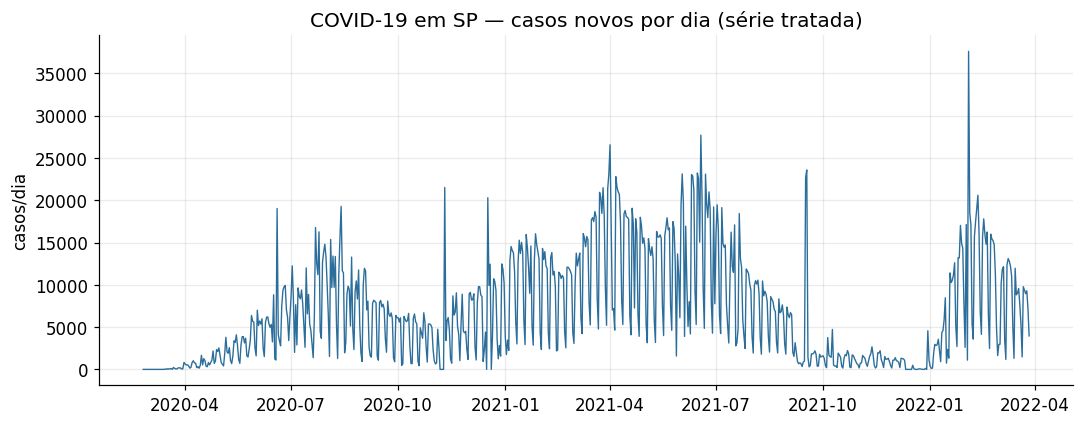

In [5]:
# série usada daqui pra frente (indexada por data, frequência diária)
casos = serie.set_index("date")["new_confirmed"].asfreq("D")
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(casos.index, casos.values, color=AZUL, lw=0.9)
ax.set_title("COVID-19 em SP — casos novos por dia (série tratada)")
ax.set_ylabel("casos/dia"); plt.tight_layout(); plt.show()

## 2. Distribuição dos dados

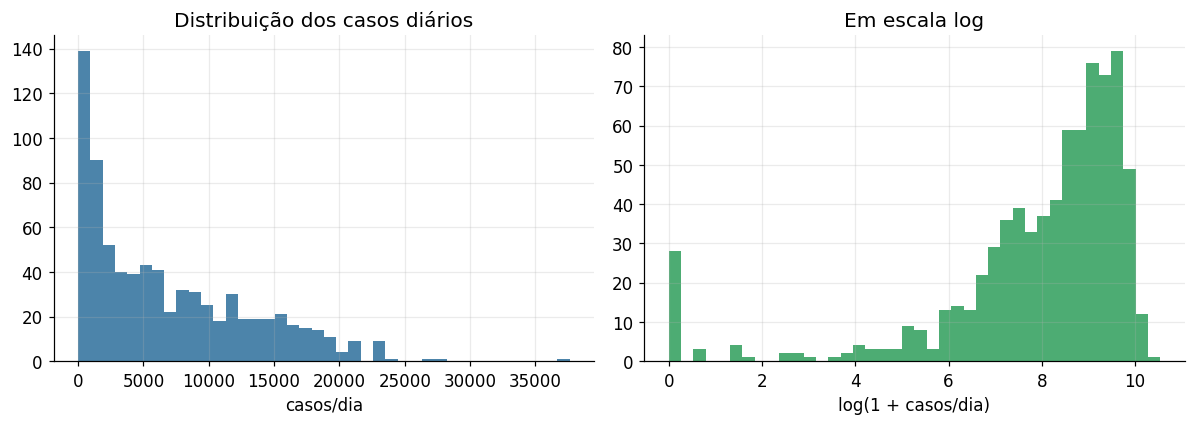

In [6]:
y = serie["new_confirmed"]
fig, axs = plt.subplots(1, 2, figsize=(11, 4))
axs[0].hist(y, bins=40, color=AZUL, alpha=0.85)
axs[0].set_title("Distribuição dos casos diários"); axs[0].set_xlabel("casos/dia")
axs[1].hist(np.log1p(y), bins=40, color=VERDE, alpha=0.85)
axs[1].set_title("Em escala log"); axs[1].set_xlabel("log(1 + casos/dia)")
plt.tight_layout(); plt.show()

A distribuição é **fortemente assimétrica à direita**; o **logaritmo** a
equilibra (por isso modelaremos em `log(1+casos)` para estabilizar a variância).

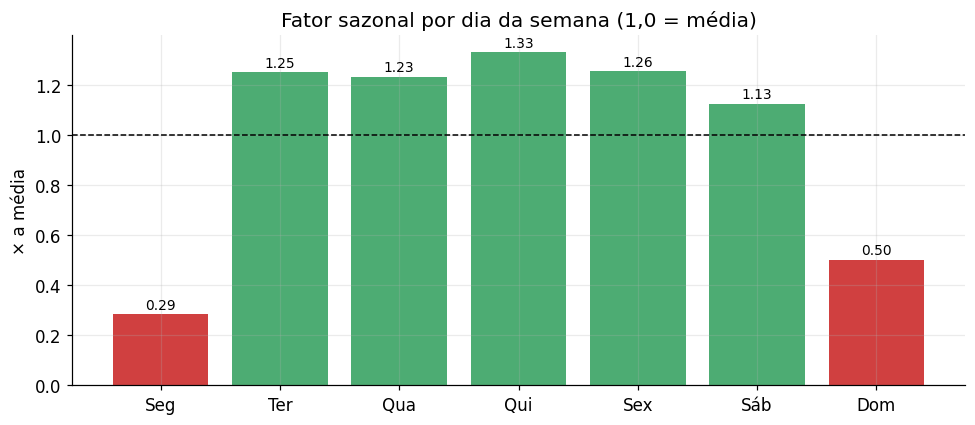

In [7]:
dias_pt = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]
serie["dow"] = serie["date"].dt.dayofweek
fatores = serie.groupby("dow")["new_confirmed"].mean() / y.mean()
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(dias_pt, fatores.values, color=[VERM if f < 1 else VERDE for f in fatores.values], alpha=0.85)
ax.axhline(1.0, color="black", ls="--", lw=1)
for i, f in enumerate(fatores.values): ax.text(i, f + 0.02, f"{f:.2f}", ha="center", fontsize=9)
ax.set_title("Fator sazonal por dia da semana (1,0 = média)"); ax.set_ylabel("× a média")
plt.tight_layout(); plt.show()

**O "dado sujo":** fins de semana registram menos (domingo ≈ metade;
segunda a mais baixa) e o meio da semana registra mais (quinta ≈ 1,4×). É efeito da
**notificação**, não da doença — e cria uma **sazonalidade semanal (período = 7)**.

## 3. Análise de série temporal

Antes de modelar, usamos as ferramentas próprias de série temporal para
**entender a estrutura** da série.

### 3.1 Decomposição
Separamos a série (em log) em **tendência + sazonalidade + resíduo**.

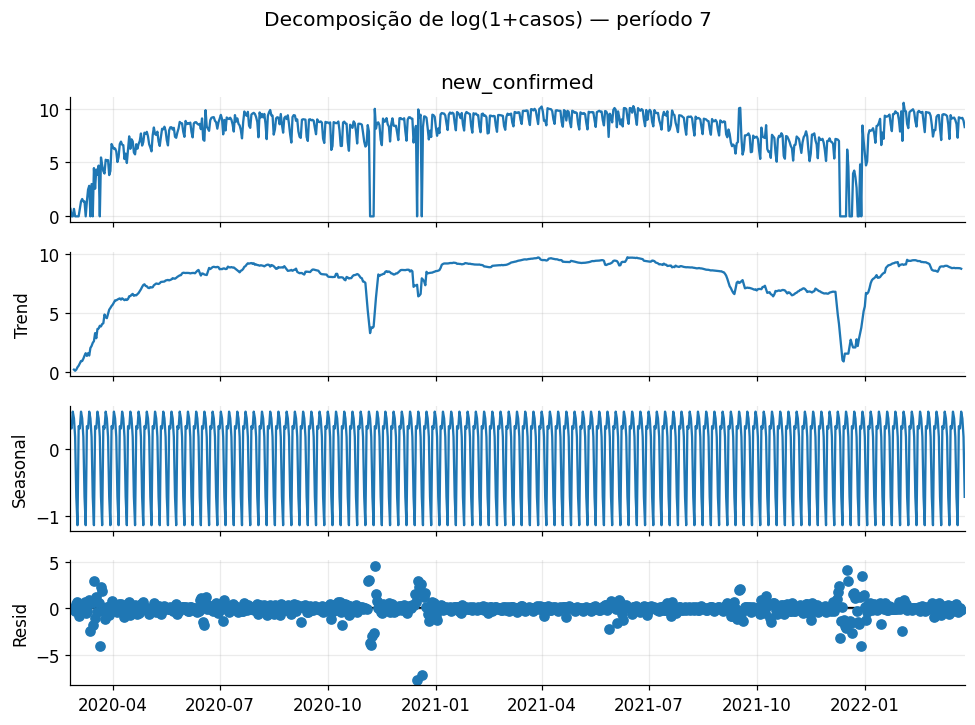

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose
dec = seasonal_decompose(np.log1p(casos), model="additive", period=7)
fig = dec.plot(); fig.set_size_inches(9, 6.5)
for a in fig.axes: a.grid(alpha=0.25)
fig.suptitle("Decomposição de log(1+casos) — período 7", y=1.01)
plt.tight_layout(); plt.show()

**Leitura:** a **tendência** capta as ondas epidêmicas; a **sazonalidade**
mostra o padrão semanal estável; o **resíduo** é o que sobra (choques irregulares).

### 3.2 Estacionariedade (ADF e KPSS)
Modelos ARIMA exigem uma série **estacionária** (média/variância estáveis no tempo).
Testamos com **ADF** (H₀ = não estacionária) e **KPSS** (H₀ = estacionária).

In [9]:
from statsmodels.tsa.stattools import adfuller, kpss
z = np.log1p(casos).dropna()
def testar(x, nome):
    adf_p = adfuller(x)[1]
    kpss_p = kpss(x, regression="c", nlags="auto")[1]
    print(f"{nome:16s} | ADF p={adf_p:.4f}  | KPSS p={kpss_p:.4f}")
print("(ADF: p<0,05 = estacionária | KPSS: p<0,05 = NÃO estacionária)")
testar(z, "nível (log)")
testar(z.diff().dropna(), "1ª diferença")

(ADF: p<0,05 = estacionária | KPSS: p<0,05 = NÃO estacionária)
nível (log)      | ADF p=0.0017  | KPSS p=0.0444
1ª diferença     | ADF p=0.0000  | KPSS p=0.0417


**Leitura:** em **nível** os testes divergem (a sazonalidade atrapalha); após a
**1ª diferença** a série fica **estacionária** — indicando `d = 1` para o ARIMA.

### 3.3 ACF e PACF
Os correlogramas identificam a estrutura (ordens `p`, `q`) e revelam a sazonalidade.

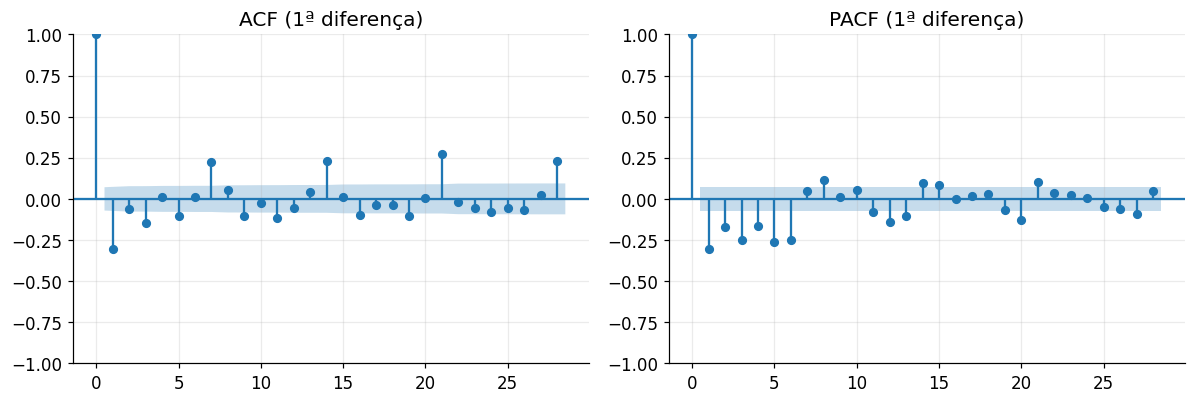

In [10]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
dz = np.log1p(casos).diff().dropna()
fig, axs = plt.subplots(1, 2, figsize=(11, 3.8))
plot_acf(dz, lags=28, ax=axs[0]); axs[0].set_title("ACF (1ª diferença)")
plot_pacf(dz, lags=28, ax=axs[1], method="ywm"); axs[1].set_title("PACF (1ª diferença)")
plt.tight_layout(); plt.show()

**Leitura:** aparecem picos claros em **7, 14, 21** → confirmam a
**sazonalidade semanal**. É isso que motiva um modelo **SARIMA** (ARIMA + sazonal).

## 4. Treino + teste (no tempo)

Em série temporal o teste tem que vir **depois** do treino (senão usaríamos o futuro
para prever o passado). Todos os modelos usam **a mesma divisão**:

- **Treino:** até **31/10/2021**.
- **Teste:** os **28 dias seguintes** (nov/2021) — período entre ondas, com padrão
  semanal claro.

Treino: 615 dias (até 2021-10-31)
Teste : 28 dias (01/11/2021 a 28/11/2021)


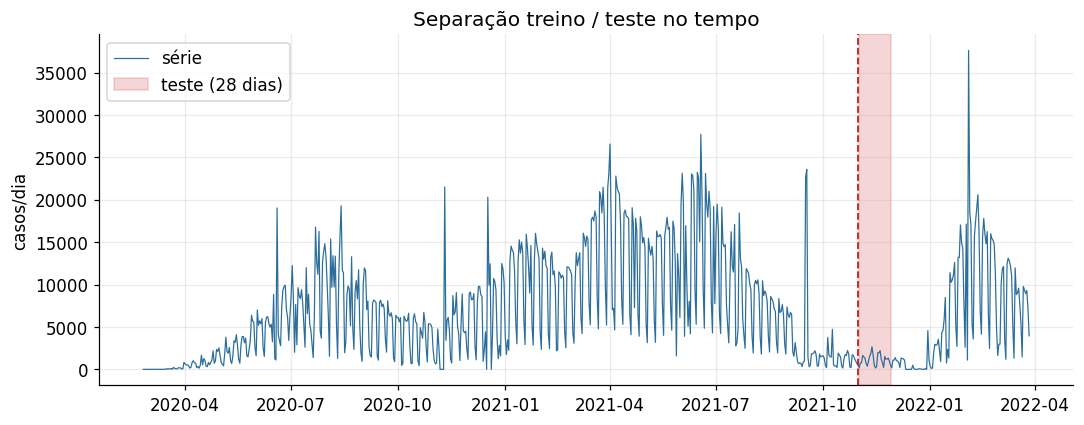

In [11]:
CORTE = "2021-10-31"; H = 28
treino = casos.loc[:CORTE]
teste = casos.loc[CORTE:].iloc[1:H+1]
print(f"Treino: {len(treino)} dias (até {CORTE})")
print(f"Teste : {len(teste)} dias ({teste.index[0]:%d/%m/%Y} a {teste.index[-1]:%d/%m/%Y})")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(casos.index, casos.values, color=AZUL, lw=0.8, label="série")
ax.axvspan(teste.index[0], teste.index[-1], color=VERM, alpha=0.18, label="teste (28 dias)")
ax.axvline(pd.Timestamp(CORTE), color=VERM, ls="--", lw=1.2)
ax.set_title("Separação treino / teste no tempo"); ax.set_ylabel("casos/dia")
ax.legend(loc="upper left"); plt.tight_layout(); plt.show()

def metricas(real, prev):
    real, prev = np.asarray(real, float), np.asarray(prev, float)
    rmse = float(np.sqrt(np.mean((real - prev)**2)))
    mae = float(np.mean(np.abs(real - prev)))
    return rmse, mae

## 5. Modelos clássicos de série temporal

Estes são os modelos **do curso** — e fazem uma **previsão de verdade dos 28 dias**
(não espiam o futuro).

### 5.1 Linha de base: Naïve sazonal
O palpite mais simples: "a próxima semana será igual à última". Serve de régua.

In [12]:
ultima_semana = treino.iloc[-7:].values
naive = np.tile(ultima_semana, int(np.ceil(H/7)))[:H]
rmse, mae = metricas(teste.values, naive); placar["Naïve sazonal"] = rmse
print(f"Naïve sazonal   -> RMSE={rmse:.0f}  MAE={mae:.0f}")

Naïve sazonal   -> RMSE=652  MAE=484


### 5.2 Holt-Winters (alisamento exponencial com sazonalidade)
Faz médias do passado com pesos que decaem, aprendendo **nível + tendência +
sazonalidade semanal**. Modelamos em `log(1+casos)`.

In [13]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
hw = ExponentialSmoothing(np.log1p(treino), trend="add", damped_trend=True,
                          seasonal="add", seasonal_periods=7).fit()
prev_hw = np.expm1(hw.forecast(H)).values
rmse, mae = metricas(teste.values, prev_hw); placar["Holt-Winters"] = rmse
print(f"Holt-Winters    -> RMSE={rmse:.0f}  MAE={mae:.0f}")

Holt-Winters    -> RMSE=498  MAE=366


### 5.3 SARIMA (ARIMA + sazonalidade)
`SARIMA(2,1,2)(1,1,1)₇`: modela diretamente a autocorrelação e o ciclo de 7 dias.

In [14]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
sarima = SARIMAX(np.log1p(treino), order=(2, 1, 2), seasonal_order=(1, 1, 1, 7),
                 enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
prev_sarima = np.expm1(sarima.forecast(H)).values
rmse, mae = metricas(teste.values, prev_sarima); placar["SARIMA"] = rmse
print(f"SARIMA          -> RMSE={rmse:.0f}  MAE={mae:.0f}")

# ARIMA sem sazonalidade, para contraste
from statsmodels.tsa.arima.model import ARIMA
arima = ARIMA(np.log1p(treino), order=(2, 1, 2)).fit()
prev_arima = np.expm1(arima.forecast(H)).values
rmse, mae = metricas(teste.values, prev_arima); placar["ARIMA"] = rmse
print(f"ARIMA (s/ sazon.) -> RMSE={rmse:.0f}  MAE={mae:.0f}")

SARIMA          -> RMSE=567  MAE=432


ARIMA (s/ sazon.) -> RMSE=714  MAE=580


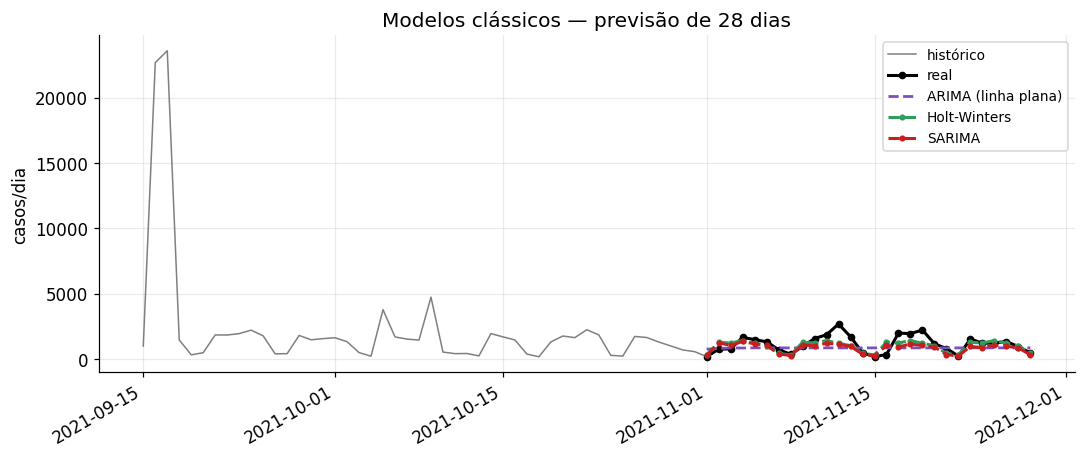

In [15]:
# previsões clássicas vs. realidade
fig, ax = plt.subplots(figsize=(10, 4.3))
ctx = casos.loc["2021-09-15":teste.index[-1]]
ax.plot(ctx.index, ctx.values, color="0.5", lw=1, label="histórico")
ax.plot(teste.index, teste.values, "-o", color="black", lw=2, ms=4, label="real")
ax.plot(teste.index, prev_arima, "--", color=ROXO, lw=1.8, label="ARIMA (linha plana)")
ax.plot(teste.index, prev_hw, "--o", color=VERDE, lw=2, ms=3, label="Holt-Winters")
ax.plot(teste.index, prev_sarima, "--o", color=VERM, lw=2, ms=3, label="SARIMA")
ax.set_title("Modelos clássicos — previsão de 28 dias"); ax.set_ylabel("casos/dia")
ax.legend(fontsize=9); fig.autofmt_xdate(); plt.tight_layout(); plt.show()

**Leitura:** o **ARIMA** prevê quase uma **linha plana** (ignora a semana); já
**Holt-Winters** e **SARIMA** reproduzem o **zigue-zague semanal** — por isso erram menos.

## 6. Alternativa automática: LazyPredict

Até aqui, escolhemos e ajustamos cada modelo **à mão**. A ferramenta sugerida pelo
professor faz o caminho automático: transformamos a série numa **tabela** (pistas =
o passado) e o **LazyPredict testa dezenas de modelos de uma vez**, ranqueando.

> **Observação:** aqui a avaliação é **um passo à frente** (usa o valor real do dia
> anterior como pista) — tarefa mais fácil que os 28 dias "cegos" dos modelos acima.

In [16]:
def montar_tabela(serie):
    d = serie.sort_values("date").reset_index(drop=True)
    yy = d["new_confirmed"].astype(float)
    tab = pd.DataFrame({"date": d["date"], "y": yy})
    for L in (1, 2, 3, 7, 14): tab[f"lag_{L}"] = yy.shift(L)
    tab["media_7d"] = yy.shift(1).rolling(7).mean()
    tab["max_7d"] = yy.shift(1).rolling(7).max()
    dow = d["date"].dt.dayofweek
    for k in range(7): tab[f"dow_{k}"] = (dow == k).astype(int)
    tab["t"] = np.arange(len(tab))
    return tab.dropna().reset_index(drop=True)

tab = montar_tabela(serie)
feats = [c for c in tab.columns if c not in ("y", "date")]
ci = int((tab["date"] <= CORTE).sum())
X_tr, y_tr = tab[feats].values[:ci], tab["y"].values[:ci]
X_te, y_te = tab[feats].values[ci:ci+H], tab["y"].values[ci:ci+H]
print(f"Tabela: {tab.shape[0]} linhas × {len(feats)} pistas | treino={len(y_tr)} teste={len(y_te)}")
tab[["date", "y", "lag_1", "lag_7", "media_7d", "dow_3"]].head(6)

Tabela: 748 linhas × 15 pistas | treino=601 teste=28


,date,y,lag_1,lag_7,media_7d,dow_3
0,2020-03-10,3.0,0.0,0.0,2.000000,0
1,2020-03-11,11.0,3.0,1.0,2.428571,0
2,2020-03-12,16.0,11.0,3.0,3.857143,1
3,2020-03-13,0.0,16.0,4.0,5.714286,0
4,2020-03-14,19.0,0.0,3.0,5.142857,0
5,2020-03-15,0.0,19.0,3.0,7.428571,0


In [17]:
from lazypredict.Supervised import LazyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
reg = LazyRegressor(verbose=0, ignore_warnings=True, predictions=True)
modelos, previsoes = reg.fit(X_tr, X_te, y_tr, y_te)
linhas = []
for nome in previsoes.columns:
    yhat = np.asarray(previsoes[nome], float)
    if not np.all(np.isfinite(yhat)): continue
    linhas.append({"modelo": nome,
                   "RMSE": float(np.sqrt(mean_squared_error(y_te, yhat))),
                   "MAE": float(mean_absolute_error(y_te, yhat))})
rank = pd.DataFrame(linhas).sort_values("RMSE").reset_index(drop=True)
print(f"{len(rank)} modelos testados. Top 6:")
rank.head(6).round(1)

39 modelos testados. Top 6:


,modelo,RMSE,MAE
0,BaggingRegressor,593.3,448.4
1,RandomForestRegressor,624.5,483.0
2,ExtraTreesRegressor,780.9,553.4
3,HistGradientBoostingRegressor,803.5,687.5
4,ExtraTreeRegressor,1015.6,690.8
5,PassiveAggressiveRegressor,1022.3,863.1


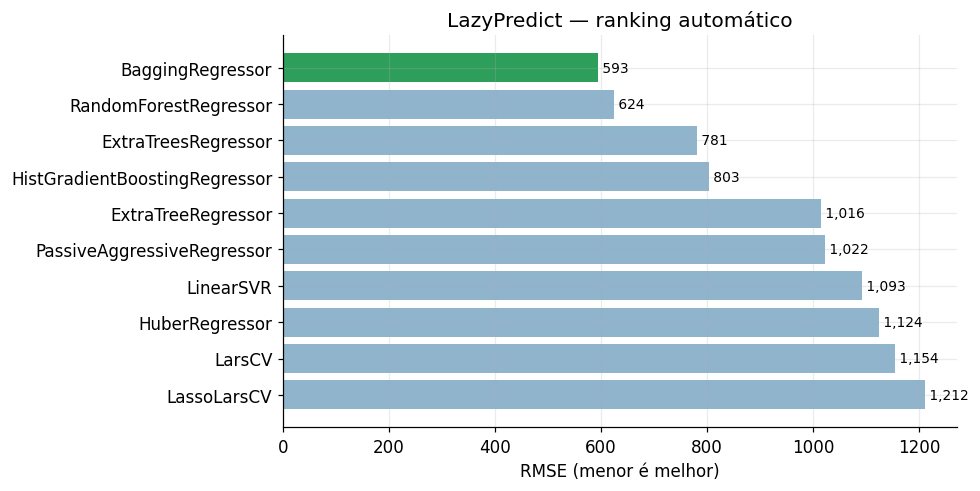

Melhor automático: BaggingRegressor RMSE 593


In [18]:
top = rank.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 4.6))
cores = [VERDE if i == len(top)-1 else "#8FB4CC" for i in range(len(top))]
ax.barh(top["modelo"], top["RMSE"], color=cores)
for i, v in enumerate(top["RMSE"]): ax.text(v, i, f" {v:,.0f}", va="center", fontsize=9)
ax.set_xlabel("RMSE (menor é melhor)"); ax.set_title("LazyPredict — ranking automático")
plt.tight_layout(); plt.show()

melhor = rank.iloc[0]["modelo"]
placar[f"LazyPredict ({melhor})"] = float(rank.iloc[0]["RMSE"])
print("Melhor automático:", melhor, "RMSE", round(rank.iloc[0]['RMSE']))

## 7. Comparação geral

Todos os modelos na **mesma janela de teste** (28 dias de nov/2021).

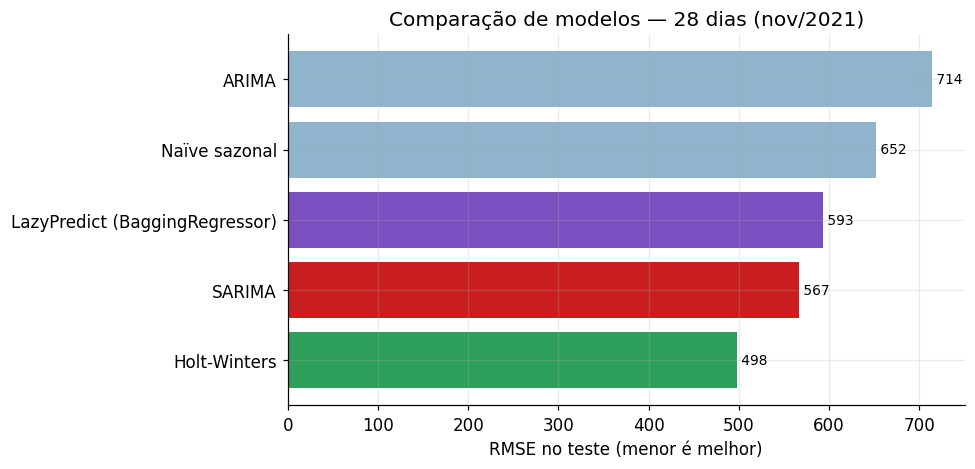

,RMSE
Holt-Winters,498.0
SARIMA,567.0
LazyPredict (BaggingRegressor),593.0
Naïve sazonal,652.0
ARIMA,714.0


In [19]:
comp = pd.Series(placar).sort_values()
fig, ax = plt.subplots(figsize=(9, 4.4))
cores = [VERDE if "Holt" in m else (VERM if "SARIMA" == m else
         (ROXO if "LazyPredict" in m else "#8FB4CC")) for m in comp.index]
ax.barh(comp.index, comp.values, color=cores)
for i, v in enumerate(comp.values): ax.text(v, i, f" {v:,.0f}", va="center", fontsize=9)
ax.set_xlabel("RMSE no teste (menor é melhor)")
ax.set_title("Comparação de modelos — 28 dias (nov/2021)")
plt.tight_layout(); plt.show()
comp.round(0).to_frame("RMSE")

## 8. Conclusões

- **É um problema de série temporal:** a decomposição, os testes de estacionariedade
  e a **ACF/PACF** revelaram uma **sazonalidade semanal (período 7)** causada pela
  notificação — a estrutura-chave a ser modelada.
- **Os modelos que capturam a sazonalidade vencem:** **Holt-Winters** e **SARIMA**
  batem folgado o ARIMA (que prevê linha plana) e o naïve. A sazonalidade é o que
  mais importa nesta série.
- **A alternativa automática (LazyPredict)** — sugerida pelo professor — chega
  perto com **uma linha de código**, testando dezenas de modelos. Ótima para
  **explorar rápido** qual família de modelo vale a pena.

**Honestidade científica (limitações):**
- O acerto **dia a dia** é limitado — o dado é ruidoso por causa da notificação;
  os modelos acertam bem o **nível e a forma** da curva.
- A avaliação do LazyPredict é **um passo à frente** (usa o dia anterior real),
  então sua comparação com os clássicos (que preveem 28 dias de uma vez) tem esse
  asterisco.
- **Conclusão madura:** automatizar acha um bom ponto de partida rápido, mas
  **conhecer a série** (e escolher um modelo sazonal) ainda dá o melhor resultado.